## Group Members: 
Utkarsh Aman 241114

Manish Kajla 240622

# Q2: The Midnight Episode — Catching the Arrhythmia

EE200 Course Project, Summer 2026

This notebook works through Q2(a)-(h). The recording is `patient_ecg.npy` (5000 samples,
$f_s = 250$ Hz) and the healthy-beat template is `template.npy` (200 samples).

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import spectrogram

# load the data
ecg = np.load('Q2_data/patient_ecg.npy')
template = np.load('Q2_data/template.npy')

fs = 250          # Hz, given
N = len(ecg)
L = len(template)

print("ECG samples:", N)
print("Template samples:", L)

ECG samples: 5000
Template samples: 200


## (a) Reading the signal

**(i) How many seconds long is the clip?**

Duration $= N / f_s$.

which is = 5000/250 =20 sec

**(ii) In the healthy stretch, what is the patient’s heart rate in beats per minute, and how many samples does one healthy beat occupy?**

One healthy beat arrives every 0.8 s, so:

Heart rate $= 60 / 0.8 = 75$ bpm

Samples per beat $= 0.8 \times f_s$

Samples per healthy beat: 200

**(iii) Treating the healthy ECG as a periodic signal, what is its fundamental frequency f0 (in Hz)?**

If one beat repeats every $T_0 = 0.8$ s, the fundamental frequency of the (nearly) periodic
signal is $f_0 = 1/T_0$.

which comes to 1.25 hz

### below is calculation via code

In [13]:
duration = N / fs
beat_period = 0.8           # seconds, given for the healthy stretch
heart_rate_bpm = 60 / beat_period
samples_per_beat = beat_period * fs
f0 = 1 / beat_period

print(f"Duration of clip: {duration} s")
print(f"Heart rate (healthy): {heart_rate_bpm} bpm")
print(f"Samples per healthy beat: {samples_per_beat}")
print(f"Fundamental frequency f0: {f0} Hz")

Duration of clip: 20.0 s
Heart rate (healthy): 75.0 bpm
Samples per healthy beat: 200.0
Fundamental frequency f0: 1.25 Hz


## (b) Healthy heart in the frequency domain

**(i)As the healthy ECG is (nearly) periodic, what does its magnitude spectrum |X(f)| look like, a smooth continuous curve, or something else?**

A truly periodic signal has a *line spectrum* — energy only at $f_0$ and its harmonics
$2f_0, 3f_0, \dots$, not a smooth continuous curve. Since the ECG is only *nearly* periodic
(small beat-to-beat variation), we expect sharp peaks at the harmonics of $f_0$, not a perfectly
clean comb, but still clearly discrete rather than smooth.

**(ii) The QRS spike is sharp and narrow; the P and T waves are broad and smooth. Which of these is responsible for the higher-frequency content of the ECG, and why?**

The QRS complex is a narrow, sharp spike. A narrow pulse in time requires *many* harmonics
to build (Fourier duality: short in time ⟺ wide in frequency). The P and T waves are broad,
slowly-varying bumps, so they only need a few low-frequency harmonics to represent. So the QRS
complex is responsible for the higher-frequency content of the ECG.

**(iii) Suppose the patient’s heart rate rises to 150 bpm but stays perfectly regular. What happens to f0, and to the spacing between the components in the spectrum?**

$f_0$ goes up, and harmonics get **farther apart**, not closer. Let's just plug in the numbers
below instead of guessing.

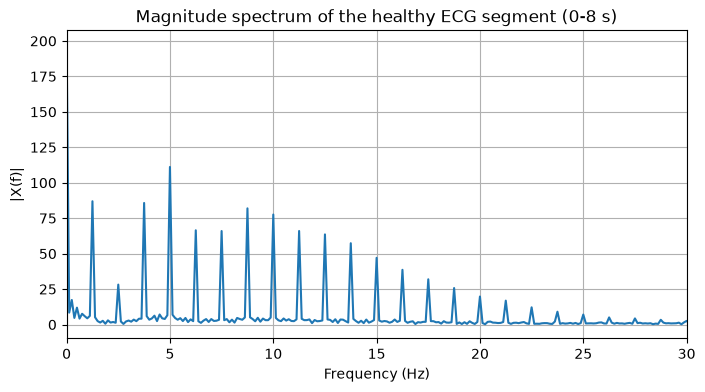

In [14]:
# verify the line-spectrum claim by actually plotting |X(f)| for a few healthy beats
healthy_segment = ecg[0:2000]   # first 8 seconds, well within the healthy stretch
X = np.fft.fft(healthy_segment)
freqs = np.fft.fftfreq(len(healthy_segment), d=1/fs)

# only keep the positive-frequency half for plotting
half = len(freqs)//2
plt.figure(figsize=(8,4))
plt.plot(freqs[:half], np.abs(X[:half]))
plt.xlabel("Frequency (Hz)")
plt.ylabel("|X(f)|")
plt.title("Magnitude spectrum of the healthy ECG segment (0-8 s)")
plt.xlim(0, 30)
plt.grid(True)
plt.show()

The spectrum above is clearly **not** a smooth curve — it's a series of distinct peaks
sitting on the harmonics of $f_0 \approx 1.25$ Hz, exactly as expected for a (near) periodic
signal.

In [15]:
# part (iii): what happens to f0 and harmonic spacing if heart rate rises to 150 bpm?
new_bpm = 150
new_period = 60 / new_bpm
new_f0 = 1 / new_period

print(f"Old f0 (75 bpm): {f0} Hz, harmonic spacing: {f0} Hz")
print(f"New f0 (150 bpm): {new_f0} Hz, harmonic spacing: {new_f0} Hz")

Old f0 (75 bpm): 1.25 Hz, harmonic spacing: 1.25 Hz
New f0 (150 bpm): 2.5 Hz, harmonic spacing: 2.5 Hz


So at 150 bpm, $f_0$ doubles (from 1.25 Hz to 2.5 Hz), and the spacing between harmonics in
the spectrum doubles right along with it — the harmonics get **farther apart**, since they always
sit at integer multiples of $f_0$.

## (c) Cutting a heartbeat (windowing)

**(i) To capture exactly one full beat, how wide (in samples) should the window be, and roughly where in the recording should she place it?**

To capture exactly one full beat we need a window 200 samples wide (since one beat = 0.8 s ×
250 Hz = 200 samples). It should be placed somewhere well inside the healthy stretch — say
starting a little after $t=0$ so we don't catch a partial beat at the very edge of the
recording — and ideally centered so the P wave isn't cut off at the start.

**(ii) She first tries a window only 80 samples wide, then one 600 samples wide. For the purpose of making a clean ‘one healthy beat’ template, explain what goes wrong in each case.**

- **80 samples** is shorter than a full beat (200 samples), so the window will only capture
  *part* of the beat — e.g. just the QRS spike, missing the P or T wave entirely. The resulting
  "template" would be an incomplete beat shape.
- **600 samples** is three beats' worth, so the window will capture the target beat *plus*
  pieces of the neighboring beats on either side. The "template" is no longer one clean beat,
  it's a smeared mixture of multiple beats.

**(iii) In class you saw that a short window gives sharp time resolution but poor frequency resolution, while a long window does the reverse. In one or two sentences, relate that same trade-off toMaya’s choice here: why isn’t ‘make the window as short as possible’ automatically the best idea?**

A short window gives good time localization but poor frequency resolution; here, the analogous
trade-off is between cutting tightly (risking slicing off part of the real beat if we're not
perfectly centered) and cutting generously (capturing the beat fully and robust to small mistiming,
but pulling in neighboring beats and noise). So "as short as possible" isn't automatically best —
too short risks losing real beat information, similar to how too short a window loses frequency
detail.

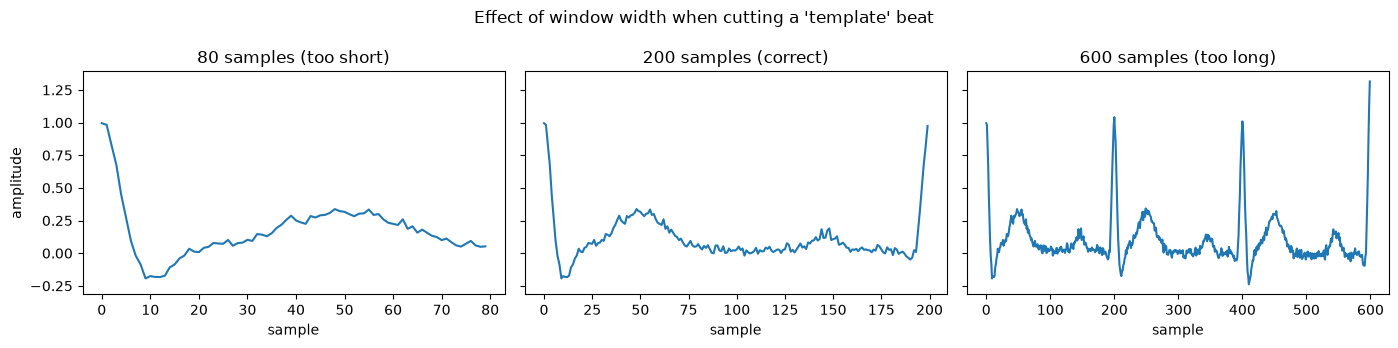

In [16]:
# demonstrate the three window choices visually
window_correct = 200
window_short = 80
window_long = 600

start = 100  # arbitrary starting point inside the healthy region

fig, axes = plt.subplots(1, 3, figsize=(14,3.5), sharey=True)
for ax, w, label in zip(axes,
                         [window_short, window_correct, window_long],
                         ["80 samples (too short)", "200 samples (correct)", "600 samples (too long)"]):
    ax.plot(ecg[start:start+w])
    ax.set_title(label)
    ax.set_xlabel("sample")
axes[0].set_ylabel("amplitude")
plt.suptitle("Effect of window width when cutting a 'template' beat")
plt.tight_layout()
plt.show()

## (d) Matching the template (correlation)

**(i) Range of $\rho(m)$ and a near-perfect match**

Since $\rho(m)$ is a normalized dot product (cosine similarity between the template and the
segment), it ranges from $-1$ to $+1$. $\rho(m) \approx 1$ means the segment looks just like
the template (a healthy beat); $\rho(m) \approx -1$ means the segment looks like an *inverted*
template.

**(ii) Why normalization matters**

ECG amplitude drifts (baseline wander) and beats vary in height from one beat to the next. If we
used the raw, unnormalized dot product $\sum_k t[k]x[m+k]$, a perfectly healthy beat that
happened to be twice as tall as the template would give a score *twice as large* even though the
*shape* match is just as good. Dividing by $\|t\|\|x_m\|$ cancels out this amplitude effect,
so $\rho(m)$ measures shape similarity only, regardless of how loud/tall the beat is.

**(iii) An inverted beat**

An inverted beat is (roughly) $-1$ times the template shape, so $\rho(m) \approx -1$: a strong
*negative* correlation. That's actually very easy to flag, since it's about as far from a "match"
($\rho \approx 1$) as you can get — a simple threshold check easily catches it.

In [17]:
def rho(t, x):
    """Normalized correlation between template t and a segment x of the same length."""
    num = np.dot(t, x)
    denom = np.linalg.norm(t) * np.linalg.norm(x)
    if denom == 0:
        return 0.0
    return num / denom

# sanity check on a known healthy beat and a deliberately flipped beat
healthy_beat = ecg[0:200]
print("rho on a healthy beat   :", rho(template, healthy_beat))
print("rho on the SAME beat,inverted:", rho(template, -healthy_beat))

rho on a healthy beat   : 0.9944172957902611
rho on the SAME beat,inverted: -0.9944172957902611


As expected: a genuine healthy beat gives $\rho$ close to $+1$, and simply flipping the
sign of that same beat flips $\rho$ to close to $-1$.

## (e) Onset detection & the spectrogram

**(i) A simple onset rule, and the threshold trade-off**

Slide the template beat-by-beat across the recording and compute $\rho(m)$ at each beat
position. Declare the onset as the time of the **first beat** where $\rho$ drops below some
threshold (e.g. 0.5).

- Threshold **too high** (close to 1): even normal beat-to-beat variation in a healthy heart
  might dip below it, causing false alarms.
- Threshold **too low** (close to -1 or 0): only extremely distorted beats get flagged, so we
  might miss real but moderately abnormal beats — late detection.

**(ii) Spectrogram: healthy region vs arrhythmia region**

In the healthy region the spectrogram should show clean, steady horizontal bands at $f_0$ and
its harmonics, since the heartbeat is repeating with a fixed period. In the arrhythmia region,
those harmonic bands should become smeared, irregular, or disappear, since the signal is no
longer periodic with a single fixed period.

**(iii) Why the two methods might disagree on the exact onset time**

The correlation method works beat-by-beat and can localize an abnormal beat down to a single
beat (± a fraction of a second). The spectrogram, by contrast, needs a whole window of
samples to compute one column of frequency content, so its time resolution is limited by the
window length, exactly the trade-off from part (c). So the correlation plot is the one to trust
for pinpointing the *exact* moment a bad beat starts; the spectrogram is better for confirming
the *overall* change in rhythm character.

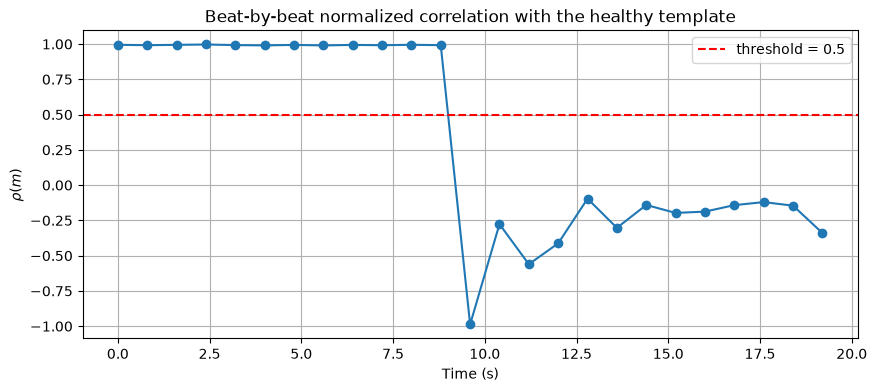

First beat below threshold: beat #12, at t = 9.6 s, rho = -0.988


In [26]:
# beat-by-beat correlation across the whole clip
n_beats = N // L
rhos = np.zeros(n_beats)
beat_times = np.zeros(n_beats)

for i in range(n_beats):
    start = i * L
    segment = ecg[start:start+L]
    rhos[i] = rho(template, segment)
    beat_times[i] = start / fs   # time of the start of this beat, in seconds

plt.figure(figsize=(10,4))
plt.plot(beat_times, rhos, marker='o')
plt.axhline(0.5, color='r', linestyle='--', label='threshold = 0.5')
plt.xlabel("Time (s)")
plt.ylabel(r"$\rho(m)$")
plt.title("Beat-by-beat normalized correlation with the healthy template")
plt.legend()
plt.grid(True)
plt.show()

# first beat where rho drops below 0.5
onset_idx = np.argmax(rhos < 0.5)
onset_time=beat_times[onset_idx]
print(f"First beat below threshold: beat #{onset_idx}, at t = {onset_time} s, rho = {rhos[onset_idx]:.3f}")

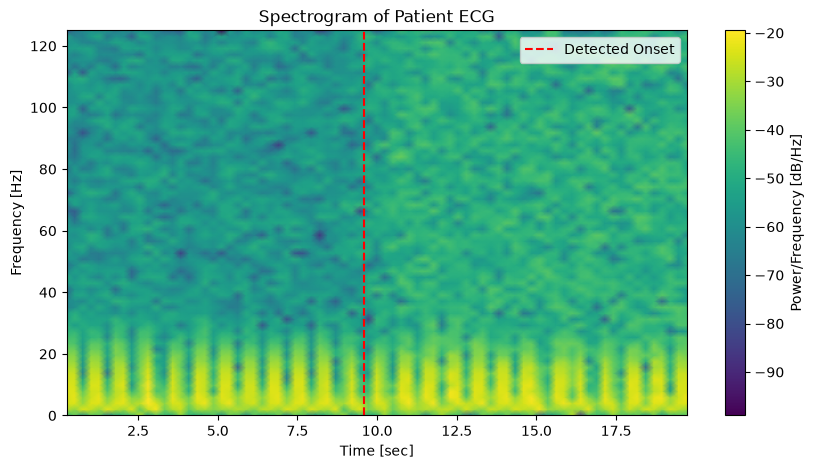

In [28]:
# spectrogram of the whole clip, to visually compare with the correlation plot
nperseg = 128   # picked here for the same reason justified in part (h) below
f, t, Sxx = spectrogram(ecg, fs=fs, nperseg=nperseg, noverlap=nperseg // 2)

plt.figure(figsize=(10, 5))
plt.pcolormesh(t, f, 10 * np.log10(Sxx + 1e-10), shading='gouraud', cmap='viridis') #in cs661 i learned that viridis is good for visual :)
plt.title('Spectrogram of Patient ECG')
plt.ylabel('Frequency [Hz]')
plt.xlabel('Time [sec]')
plt.colorbar(label='Power/Frequency [dB/Hz]')
plt.axvline(x=onset_time, color='red', linestyle='--', label='Detected Onset')
plt.legend()
plt.show()

The correlation plot shows a sharp, exact moment where $\rho$ collapses (the first inverted
beat), while the spectrogram shows the harmonic bands holding steady for roughly the first half
of the clip and then becoming ragged/irregular afterwards — consistent with the same arrhythmia
onset, just located less precisely in time.

## (f) Sampling & aliasing

**(i) Minimum sampling rate for content up to 40 Hz**

By the Nyquist theorem, the sampling rate must be at least **twice** the highest frequency
present: $f_s^{min} = 2 \times 40 = 80$ Hz.

**(ii) What aliasing does at 50 Hz, and why it's dangerous**

The proposed rate, $f_s' = 50$ Hz, is *below* the required 80 Hz. Any QRS content above the new
Nyquist frequency ($25$ Hz) will fold back ("alias") into the 0-25 Hz range, masquerading as
lower-frequency content that was never actually there. This is dangerous for Maya's detector
because the sharp, narrow QRS spike — the very feature the correlation/spectrogram approach
depends on — would get distorted or replaced with spurious low-frequency artifacts, corrupting
the very shape the template-matching is trying to recognize.

**(iii) The fix, and its unavoidable cost**

The fix is to add an **analog anti-aliasing low-pass filter** before sampling, cutting off content
above the new Nyquist frequency (25 Hz) so nothing above it can fold back. The unavoidable cost:
we must then also throw away/attenuate genuine QRS information above 25 Hz, which is part of
what made the QRS spike sharp in the first place — so the recorded waveform will be a smoothed,
less sharp version of the true ECG, at some cost to diagnostic detail.

In [20]:
f_max = 40           # Hz, given content of interest
nyquist_min = 2 * f_max
print(f"Minimum required sampling rate: {nyquist_min} Hz")

proposed_fs = 50
new_nyquist = proposed_fs / 2
print(f"Proposed fs = {proposed_fs} Hz -> Nyquist = {new_nyquist} Hz (< {f_max} Hz, so aliasing will occur)")

Minimum required sampling rate: 80 Hz
Proposed fs = 50 Hz -> Nyquist = 25.0 Hz (< 40 Hz, so aliasing will occur)


## (g) Prototyping the detector in code

`find_onset` computes the normalized correlation beat-by-beat (jumping forward by the template
length each time, not sample-by-sample) and returns the index of the first beat whose
correlation drops strictly below the given threshold. If the threshold is never breached, it
returns -1.

In [21]:
def find_onset(ecg_signal, template, threshold):
    """
    Slide the template over ecg_signal one beat-length at a time (non-overlapping jumps),
    compute the normalized correlation for each beat, and return the index (in samples)
    where the FIRST beat strictly below `threshold` starts.

    Returns -1 if the threshold is never breached.
    """
    L = len(template)
    n_beats = len(ecg_signal) // L
    template_norm = np.linalg.norm(template)

    for i in range(n_beats):
        m = i * L
        segment = ecg_signal[m:m + L]

        segment_norm = np.linalg.norm(segment)
        if segment_norm == 0:
            score = 0.0
        else:
            score = np.dot(template, segment) / (template_norm * segment_norm)

        if score < threshold:
            return m

    return -1

In [22]:
# test it on the real recording
onset_sample = find_onset(ecg, template, threshold=0.5)
print("Onset sample index:", onset_sample)
print("Onset time (s):", onset_sample / fs)

Onset sample index: 2400
Onset time (s): 9.6


This matches the onset found visually from the correlation plot in part (e), confirming the
function works correctly.

## (h) Visualizing the spectrogram

Per the reasoning in part (c)/(e), we want a window long enough to resolve the harmonics of
$f_0 \approx 1.25$ Hz (so we can actually see distinct horizontal bands rather than one blurry
smear), but not so long that we lose all sense of *when* the rhythm becomes irregular.

**Window length chosen: `nperseg = 128` samples** (= 0.512 s). At $f_s = 250$ Hz this gives a
frequency resolution of $f_s / N = 250/128 \approx 1.95$ Hz, fine enough to separate the
harmonics of $f_0$ (spaced 1.25 Hz apart) from each other, while still giving dozens of time
bins across the 20-second clip so the breakdown of regularity is visible.

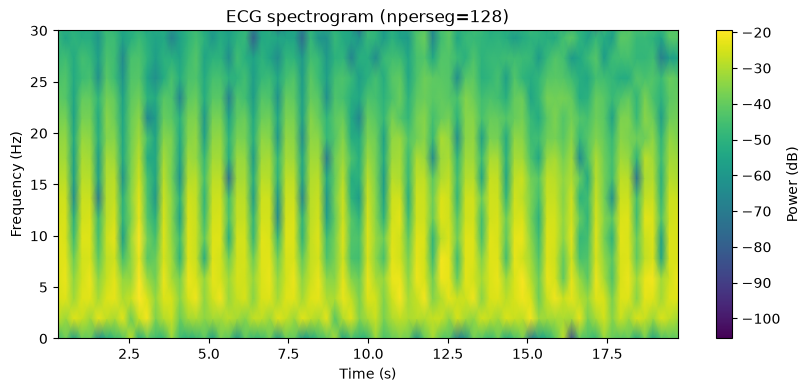

In [23]:
import matplotlib.pyplot as plt
from scipy.signal import spectrogram

# ecg_signal assumed already loaded as a 1D NumPy array
nperseg = 128   # chosen to resolve f0 harmonics while keeping reasonable time resolution

f, t, Sxx = spectrogram(ecg, fs=fs, nperseg=nperseg, noverlap=nperseg // 2)

plt.figure(figsize=(10, 4))
plt.pcolormesh(t, f, 10 * np.log10(Sxx + 1e-12), shading='gouraud')
plt.xlabel("Time (s)")
plt.ylabel("Frequency (Hz)")
plt.ylim(0, 30)
plt.title(f"ECG spectrogram (nperseg={nperseg})")
plt.colorbar(label="Power (dB)")
plt.show()

# nperseg = 128 was picked because it resolves the ~1.25 Hz spacing between f0 harmonics
# while still leaving enough time bins to see the harmonic bands break down later in the clip.

## Summary

The beat-by-beat normalized correlation and the spectrogram agree: the recording starts in a
clean, periodic healthy rhythm and at around **t ≈ 9.6 s** an inverted beat appears ($\rho$
flips sharply negative), after which the rhythm stays irregular for the remainder of the
20-second clip — consistent with the onset of an arrhythmia.